First Run with Fake Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = {
    "planet": ["Venus", "Earth", "Mars"],
    "albedo": [0.77, 0.30, 0.25],
    "solar_flux_Wm2": [2613, 1361, 590],
    "actual_temp_K": [735, 288, 210],
    "pressure_bar": [92, 1, 0.006],
    "co2_fraction": [0.965, 0.0004, 0.95]
} 
"""
making a fake dataframe and then converting it to a csv.
We need fake data for now so that we can still code and once we have real data we can just plug it in and go right ahead.
We are keeping it basic for now, making the dataframe with one value per planet per variable of interest.
"""

df = pd.DataFrame(data)
df.to_csv("planet_data.csv", index=False)
df

,planet,albedo,solar_flux_Wm2,actual_temp_K,pressure_bar,co2_fraction
0,Venus,0.77,2613,735,92.000,0.9650
1,Earth,0.30,1361,288,1.000,0.0004
2,Mars,0.25,590,210,0.006,0.9500


In [3]:
from astropy.constants import sigma_sb
from astropy import units as u
# importing units and stefan boltzmann constant from astropy to carry out the stefan boltzmann law for effective temperature

## Expected Temperature: 
If the Greenhouse Gas Effect/ Global Warming was not present:

$$
T_{\text{eff}} = \left( \frac{(1 - A) S}{4 \sigma} \right)^{1/4}
$$

This is the Stefan-Boltzmann law for effective temperature, using albedo (reflectivity) and solar flux (energy per unit area). The constant is power of a blackbody (perfect emitter). The actual law is to solve for power, but by including albedo and solar flux and manipulating the equation, we can solve for temp.

In [5]:
def expected_temp(albedo, solar_flux):
    S = solar_flux * u.W / (u.m**2)
    A = albedo
    T = ((1 - A) * S / (4 * sigma_sb))**0.25
    return T.to(u.K).value

df["expected_temp_K"] = df.apply(
    lambda row: expected_temp(row["albedo"], row["solar_flux_Wm2"]),
    axis=1
)

df["delta_T"] = df["actual_temp_K"] - df["expected_temp_K"]
df
# adding to our dataframe with these expected values and change between the expected and actual to model a correlation

,planet,albedo,solar_flux_Wm2,actual_temp_K,pressure_bar,co2_fraction,expected_temp_K,delta_T
0,Venus,0.77,2613,735,92.000,0.9650,226.881393,508.118607
1,Earth,0.30,1361,288,1.000,0.0004,254.578140,33.421860
2,Mars,0.25,590,210,0.006,0.9500,210.164997,-0.164997


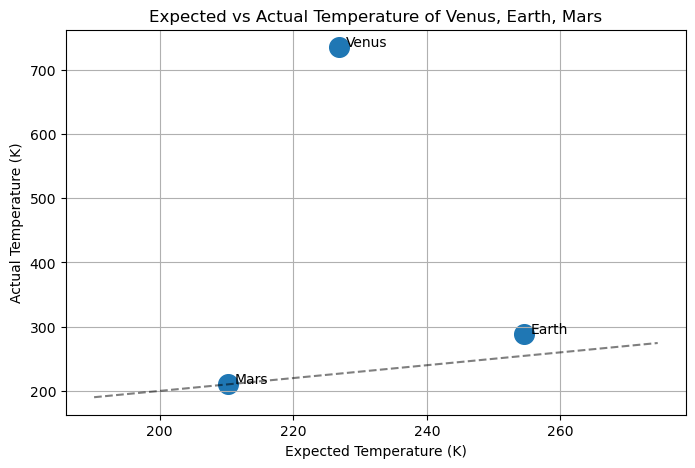

In [7]:
plt.figure(figsize=(8,5))
xmin = df["expected_temp_K"].min() - 20
xmax = df["expected_temp_K"].max() + 20

plt.plot([xmin, xmax], [xmin, xmax], "k--", alpha=0.5)
plt.scatter(df["expected_temp_K"], df["actual_temp_K"], s=200)

for i, row in df.iterrows():
    plt.text(row["expected_temp_K"]+1, row["actual_temp_K"]+1, row["planet"])

plt.xlabel("Expected Temperature (K)")
plt.ylabel("Actual Temperature (K)")
plt.title("Expected vs Actual Temperature of Venus, Earth, Mars")
plt.grid(True)
plt.show()

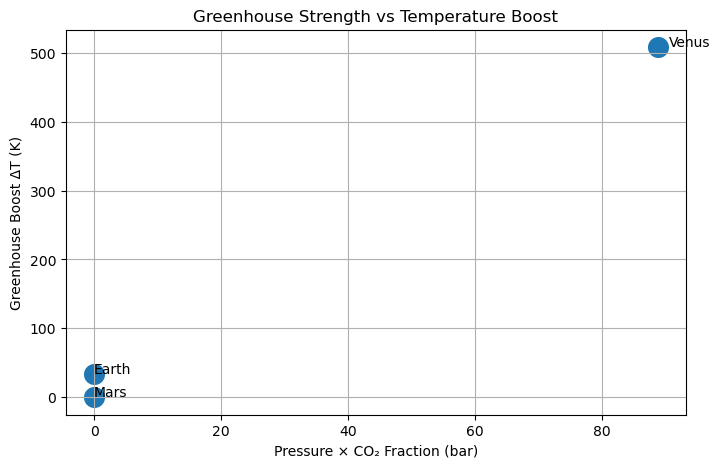

In [8]:
df["greenhouse_strength"] = df["pressure_bar"] * df["co2_fraction"]

plt.figure(figsize=(8,5))
plt.scatter(df["greenhouse_strength"], df["delta_T"], s=200)

for i, row in df.iterrows():
    plt.text(row["greenhouse_strength"]*1.02, row["delta_T"]+1, row["planet"])

plt.xlabel("Pressure × CO₂ Fraction (bar)")
plt.ylabel("Greenhouse Boost ΔT (K)")
plt.title("Greenhouse Strength vs Temperature Boost")
plt.grid(True)
plt.show()

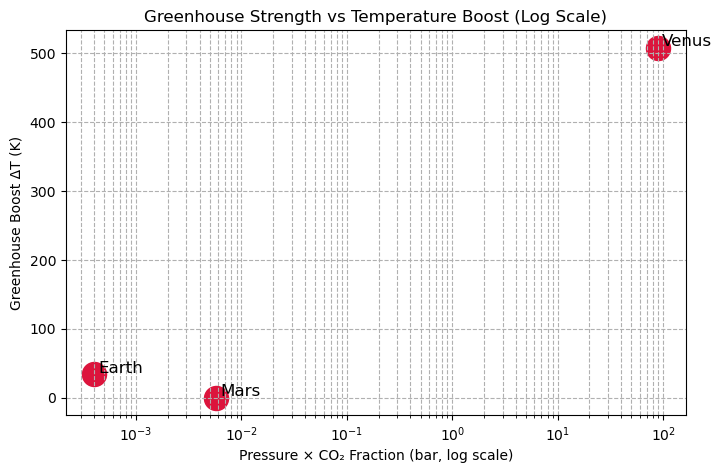

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(df["greenhouse_strength"], df["delta_T"], s=300, color="crimson")

for i, row in df.iterrows():
    plt.text(
        row["greenhouse_strength"] * 1.1,
        row["delta_T"] + 2,
        row["planet"],
        fontsize=12
    )

plt.xscale("log")

plt.xlabel("Pressure × CO₂ Fraction (bar, log scale)")
plt.ylabel("Greenhouse Boost ΔT (K)")
plt.title("Greenhouse Strength vs Temperature Boost (Log Scale)")
plt.grid(True, which="both", ls="--")
plt.show()

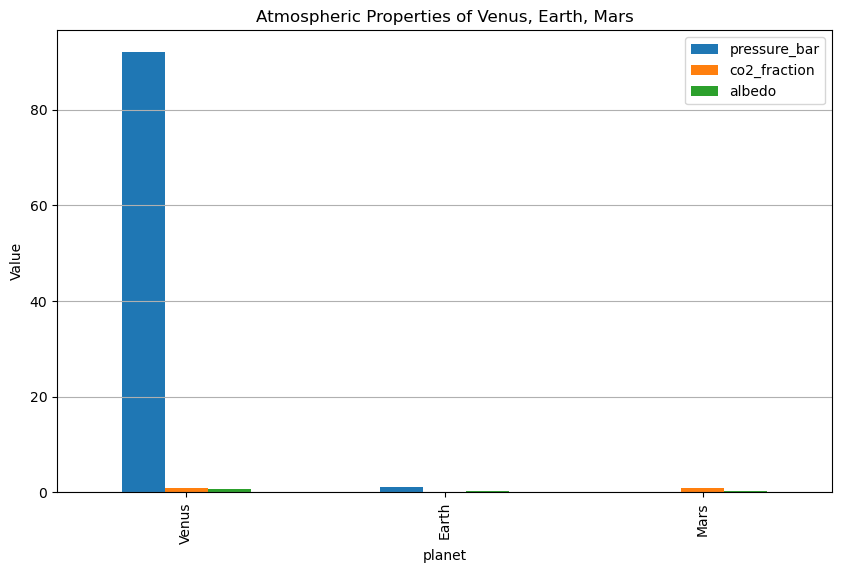

In [12]:
df.set_index("planet")[["pressure_bar", "co2_fraction", "albedo"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Atmospheric Properties of Venus, Earth, Mars")
plt.ylabel("Value")
plt.grid(axis="y")
plt.show()

In [15]:
numeric_cols = [
    "albedo",
    "solar_flux_Wm2",
    "actual_temp_K",
    "pressure_bar",
    "co2_fraction",
    "expected_temp_K",
    "delta_T",
    "greenhouse_strength"
]

df[numeric_cols] = df[numeric_cols].astype(float)
# got an error before as i tried to plot with strings so this makes sure everything is gonna be a float

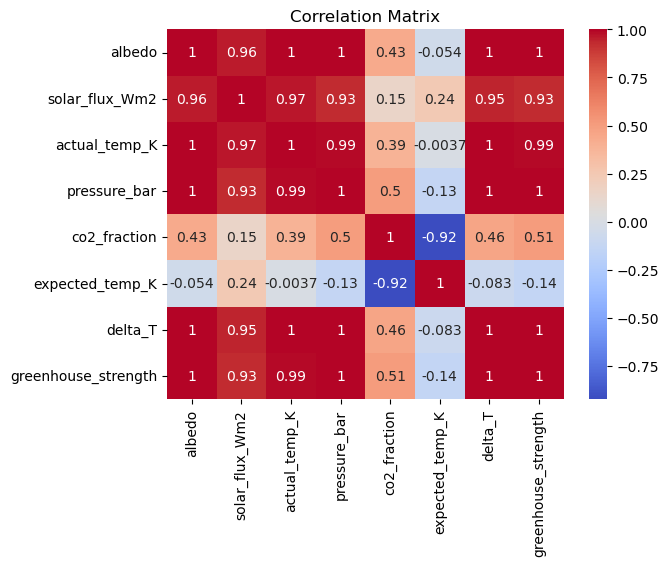

In [17]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

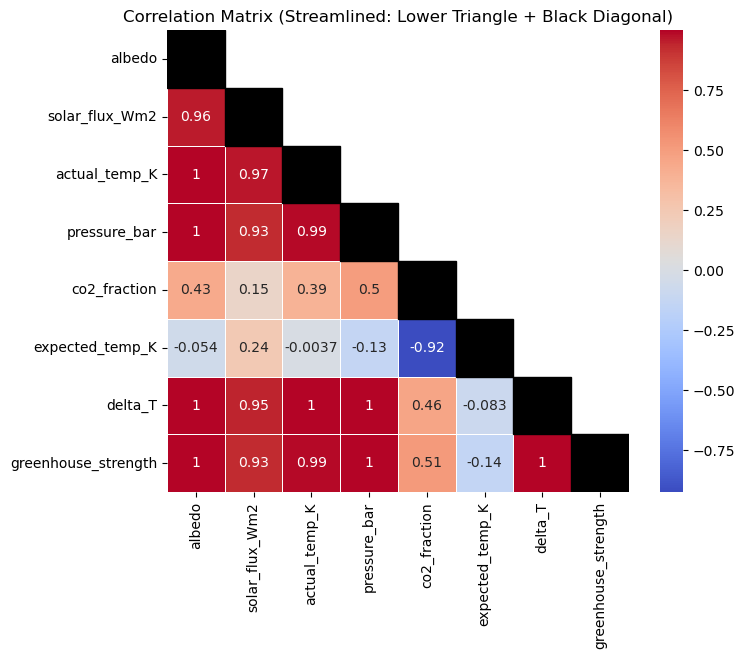

In [19]:
# want to get rid of the correlations to themselves so it declutters the map
# also want to get rid of the duplicates because right now kind of like a multiplication table that has duplicates of reversed order

corr = df.select_dtypes(include='number').corr()

# mask for the upper triangle (or lower, your choice)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))

# draw heatmap with mask
sns.heatmap(
    corr,
    mask=mask,          # hides the upper triangle
    annot=True,
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5
)

# overlay black squares on the diagonal
for i in range(len(corr)):
    plt.gca().add_patch(
        plt.Rectangle((i, i), 1, 1, fill=True, color='black', ec='black')
    )

plt.title("Correlation Matrix (Streamlined: Lower Triangle + Black Diagonal)")
plt.show()
